In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    r"C:\Users\thana\Desktop\flight_analysis\data\flight_clean.csv"
)

print("Γραμμές:", len(df))
print("Έτοιμο!")

Γραμμές: 1928371
Έτοιμο!


C:\Users\thana\AppData\Local\Temp\ipykernel_8956\1017587237.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="coolwarm")


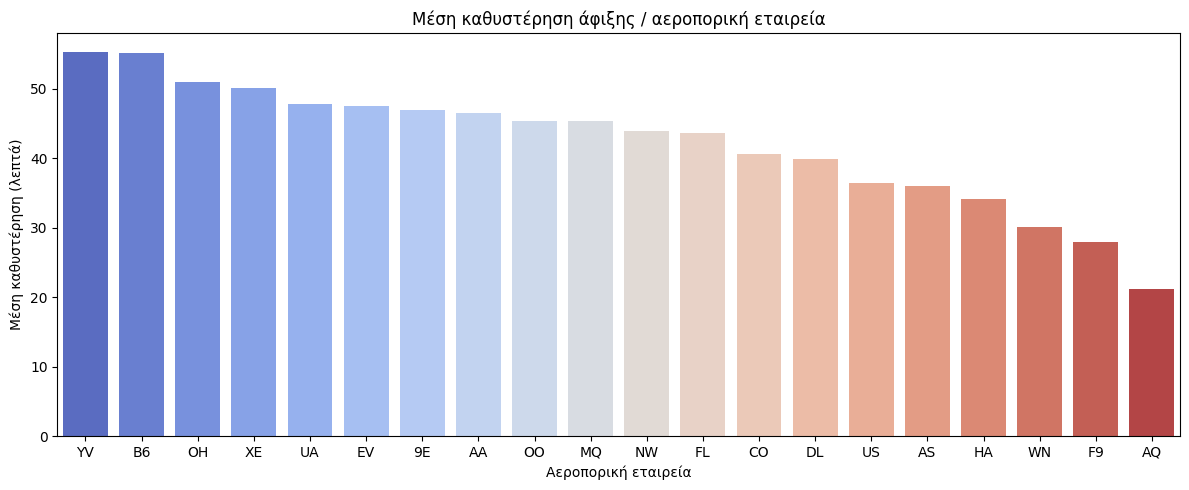

In [7]:
#Καθυστερήσεις / αεροπορική εταιρεία
plt.figure(figsize=(12, 5))
carrier_delay = df.groupby("UniqueCarrier")["ArrDelay"].mean().sort_values(ascending=False)

sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="coolwarm")
plt.title("Μέση καθυστέρηση άφιξης / αεροπορική εταιρεία")
plt.xlabel("Αεροπορική εταιρεία")
plt.ylabel("Μέση καθυστέρηση (λεπτά)")
plt.tight_layout()
plt.show()

- Οι YV και B6 έχουν την υψηλότερη μέση καθυστέρηση
- Αμέσως μετά έρχονται οι OH  και XE.
- Μια μεγάλη ομάδα εταιρειών (UA, EV, 9E, AA, OO, MQ, NW, FL), δείχνει παρόμοια επίπεδα καθυστέρησης.
- Οι CO, DL, US, AS, HA κυμαίνονται, αισθητά καλύτερα από τον μέσο όρο.
- Η WN και η F9 έχουν ιδιαίτερα καλή επίδοση.
- Η AQ είναι η καλύτερη εταιρεία του δείγματος με διαφορά.

Γενικό συμπέρασμα:
Υπάρχει σημαντική διακύμανση μεταξύ εταιρειών, η χειρότερη (YV) καθυστερεί κατά μέσο όρο 2.5× περισσότερο από την καλύτερη (AQ). Αυτό υποδηλώνει ότι ο carrier είναι σημαντικός παράγοντας πρόβλεψης καθυστέρησης.

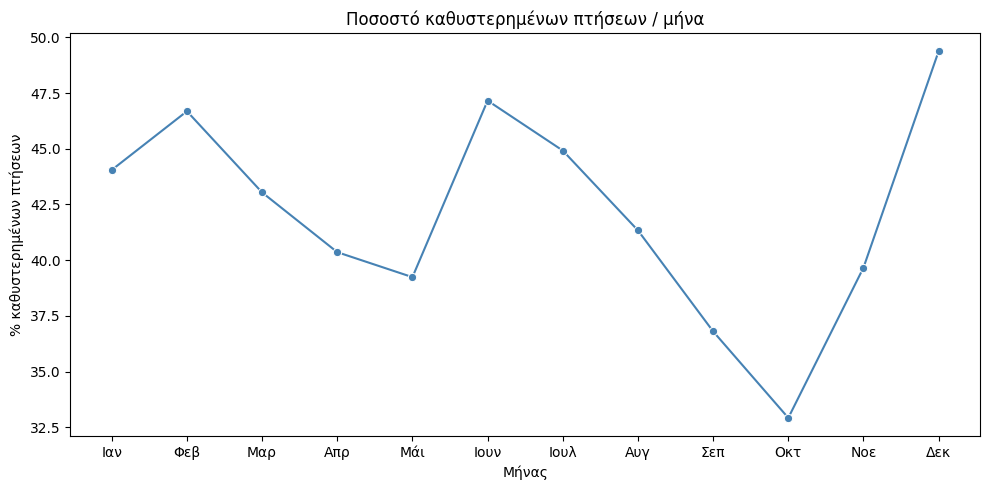

In [8]:
#Καθυστερήσεις ανά μήνα
plt.figure(figsize=(10, 5))
monthly_delay = df.groupby("Month")["DELAYED"].mean() * 100

sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker="o", color="steelblue")
plt.title("Ποσοστό καθυστερημένων πτήσεων / μήνα")
plt.xlabel("Μήνας")
plt.ylabel("% καθυστερημένων πτήσεων")
plt.xticks(range(1, 13), ["Ιαν", "Φεβ", "Μαρ", "Απρ", "Μάι", "Ιουν",
                          "Ιουλ", "Αυγ", "Σεπ", "Οκτ", "Νοε", "Δεκ"])
plt.tight_layout()
plt.show()

- Γενική εικόνα:
το ποσοστό καθυστερημένων πτήσεων κυμαίνεται μεταξύ ~33% και ~49% ανά μήνα, με εμφανή εποχικά μοτίβα κατά τη διάρκεια του χρόνου.
- Κορυφές καθυστερήσεων: Δεκέμβριος (~49%), Ιούνιος (~47%), Φεβρουάριος (~47%).
- Χαμηλότερες καθυστερήσεις: Οκτώβριος (~33%), Σεπτέμβριος (~37%) και Μάιος (~39%).
- Ο μήνας είναι ισχυρό feature για την πρόβλεψη καθυστερήσεων.

C:\Users\thana\AppData\Local\Temp\ipykernel_8956\943718477.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=means.index, y=means.values, palette="OrRd_r")


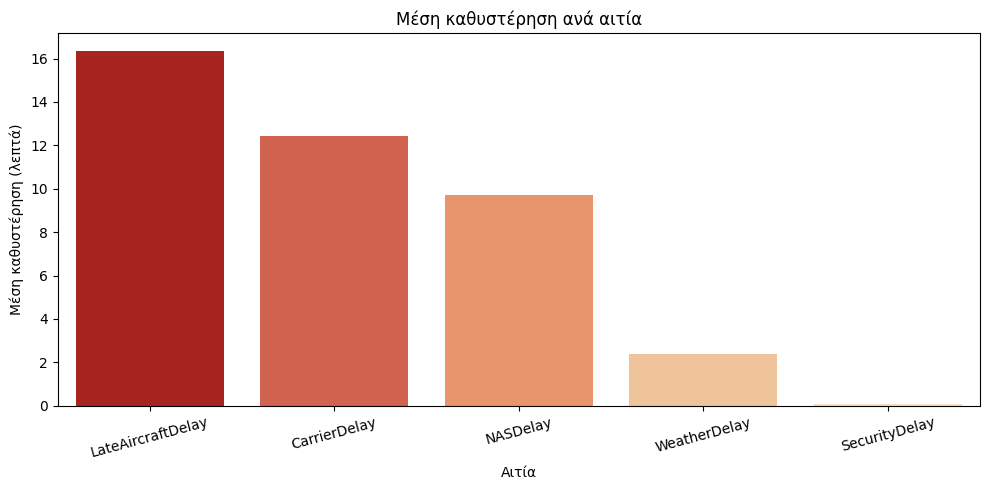

In [9]:
#Αιτίες καθυστέρησης
delay_causes = ["CarrierDelay", "WeatherDelay", "NASDelay",
                "SecurityDelay", "LateAircraftDelay"]

means = df[delay_causes]. mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=means.index, y=means.values, palette="OrRd_r")
plt.title("Μέση καθυστέρηση ανά αιτία")
plt.xlabel("Αιτία")
plt.ylabel("Μέση καθυστέρηση (λεπτά)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

- Γενικό συμπέρασμα: το γράφημα δείχνει τη μέση συνεισφορά κάθε αιτίας στην συνολική καθυστέρηση. Οι 5 κατηγορίες έχουν πολύ άνιση κατανομή, 3 κυριαρχούν και 2 είναι σχεδόν αμελητέες.
- Κυρίαρχες αιτίες: LateAircraftDelay (~16'), CarrierDelay (~12') και NASDelay (~10').
- Αμελητέες αιτίες: WeatherDelay (~2,5') και SecurityDelay (~0').

C:\Users\thana\AppData\Local\Temp\ipykernel_8956\1480690688.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_delay.index, y=weekly_delay.values, palette="Blues_d")


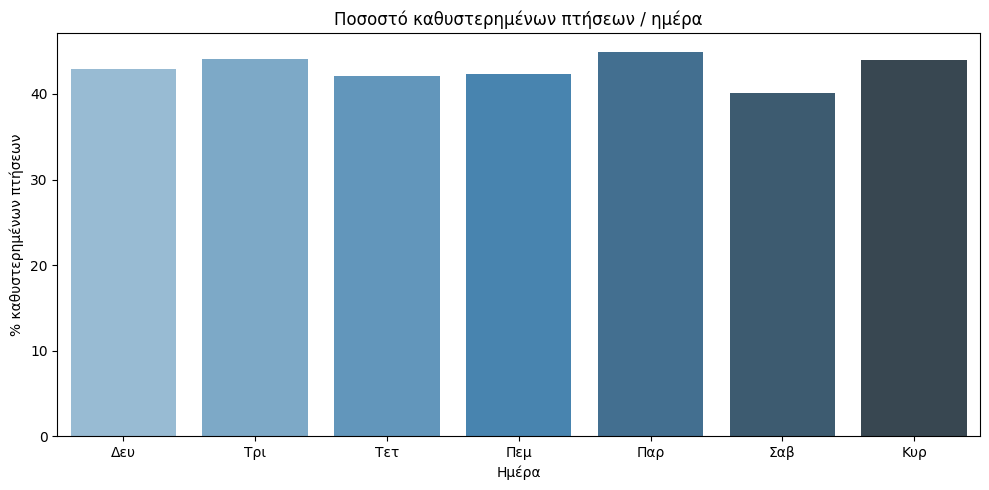

In [10]:
#Καθυστερήσεις / ημέρα της εβδομάδας
plt.figure(figsize=(10, 5))
weekly_delay = df.groupby("DayOfWeek")["DELAYED"].mean() * 100

sns.barplot(x=weekly_delay.index, y=weekly_delay.values, palette="Blues_d")
plt.title("Ποσοστό καθυστερημένων πτήσεων / ημέρα")
plt.xlabel("Ημέρα")
plt.ylabel("% καθυστερημένων πτήσεων")
plt.xticks(range(7), ["Δευ", "Τρι", "Τετ", "Πεμ", "Παρ", "Σαβ", "Κυρ"])
plt.tight_layout()
plt.show()

- Είναι το πιο "επίπεδο" γράφημα. Όλες οι μέρες κυμαίνονται με διαφορά μόλις ~5 μονάδων μεταξύ της καλύτερης και χειρότερης μέρας.
- Η ημέρα της εβδομάδας είναι το ασθενέστερο temporal feature. Συμπεριλαμβάνεται στο μοντέλο χωρίς μεγάλες προσδοκίες.

C:\Users\thana\AppData\Local\Temp\ipykernel_8956\2166344433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=period_delay.index, y=period_delay.values, palette="Purples")


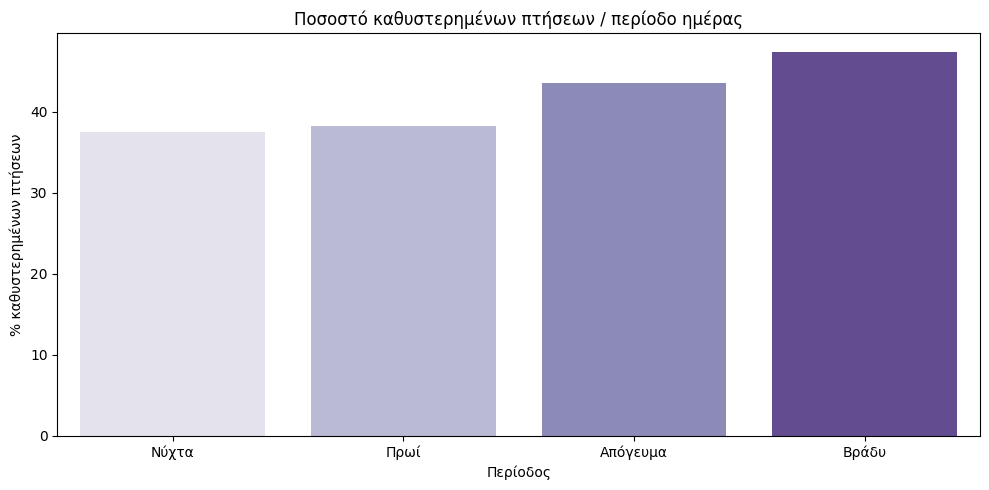

In [11]:
#Καθυστερήσεις ανά περιόδο της ημέρας
plt.figure(figsize=(10, 5))
period_delay = df.groupby("DEP_PERIOD")["DELAYED"].mean() * 100
period_delay = period_delay.reindex(["night", "morning", "afternoon", "evening"])

sns.barplot(x=period_delay.index, y=period_delay.values, palette="Purples")
plt.title("Ποσοστό καθυστερημένων πτήσεων / περίοδο ημέρας")
plt.xlabel("Περίοδος")
plt.ylabel("% καθυστερημένων πτήσεων")
plt.xticks(ticks=range(4), labels=["Νύχτα", "Πρωί", "Απόγευμα", "Βράδυ"])
plt.tight_layout()
plt.show()

- Το ποσοστό καθυστερημένων πτήσεων αυξάνεται σταδιακά καθώς προχωράει η μέρα, με εξαίρεση τη νύχτα που εμφανίζει χαμηλότερα ποσοστά από το βράδυ.
- Ανάλυση ανά περίοδο: Νύχτα (00:00-05:59) ~38%, Πρωί (06:00-11:59) ~38,5%, Απόγευμα (12:00-17:59) ~43% και Βράδυ (18:00-23:59) ~47%.
- Το πρωί και τη νύχτα υπάρχουν λιγότερες καθυστερήσεις, το απόγευμα υπάρχει αισθητή αύξηση (+5%), ενώ το βράδυ είναι η χειρότερη περίοδος.

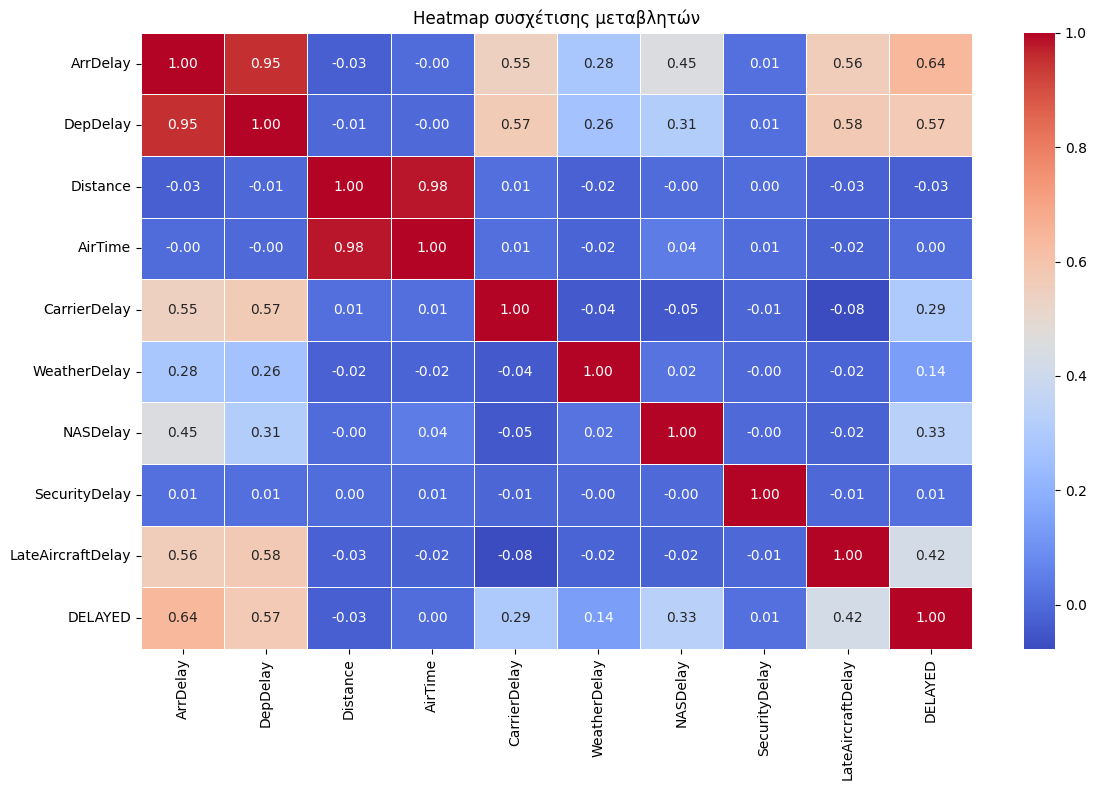

In [12]:
# Heatmap συσχέτισης μεταβλητών
plt.figure(figsize=(12, 8))
cols = ["ArrDelay", "DepDelay", "Distance", "AirTime",
        "CarrierDelay", "WeatherDelay", "NASDelay",
        "SecurityDelay", "LateAircraftDelay", "DELAYED"]

sns.heatmap(df[cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidth=0.5)
plt.title("Heatmap συσχέτισης μεταβλητών")
plt.tight_layout()
plt.show()

- Το ArrDelay <-> DepDelay έχουν σχεδόν τέλεια γραμμική σχέση. Αν καθυστερήσει η αναχώρηση, καθυστερεί και η άφιξη. 
- Το Distance <-> AirTime είναι αναμενόμενο, μεγαλύτερη απόσταση = περισσότερος χρόνος πτήσης. 
- ΣΗΜΑΝΤΙΚΟ! Τα ArrDelay, DepDelay, CarrierDelay, NASDelay, LateAircraftDelay και WeatherDelay είναι αποτελέσματα της καθυστέρησης, όχι αίτια που είναι γνωστά εκ των προτέρων. Σε real-world πρόβλεψη, θα είχαμε σοβαρό data leakage. Για το project που υλοποιείται θεωρούνται αποδεκτά.

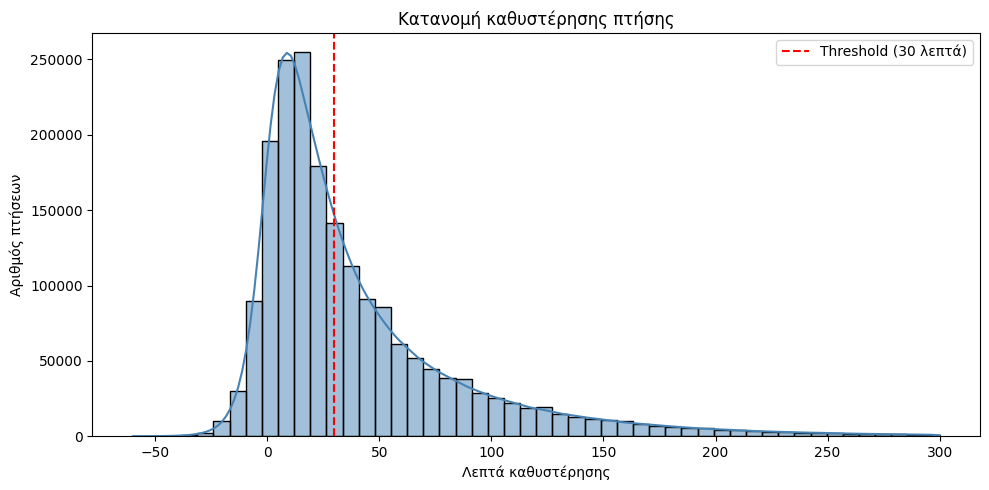

In [13]:
# ArrDelay(histogram)
plt.figure(figsize=(10, 5))
df_filtered = df[df["ArrDelay"].between(-60, 300)]

sns.histplot(df_filtered["ArrDelay"], bins=50, color="steelblue", kde=True)
plt.title("Κατανομή καθυστέρησης πτήσης")
plt.xlabel("Λεπτά καθυστέρησης")
plt.ylabel("Αριθμός πτήσεων")
plt.axvline(x=30, color="red", linestyle="--", label="Threshold (30 λεπτά)")
plt.legend()
plt.tight_layout()
plt.show()

- Η κατανομή είναι έντονα ασύμμετρη προς τα δεξιά.
- Η κόκκινη γραμμή χωρίζει το dataset σε δύο κλάσεις, επιβεβαιώνοντας ότι η πλειοψηφία των πτήσεων είναι φθάνουν νωρίτερα από την αναμενόμενη ώρα άφιξης.

C:\Users\thana\AppData\Local\Temp\ipykernel_8956\1916965039.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.index, y=top_airports.values, palette="Reds")


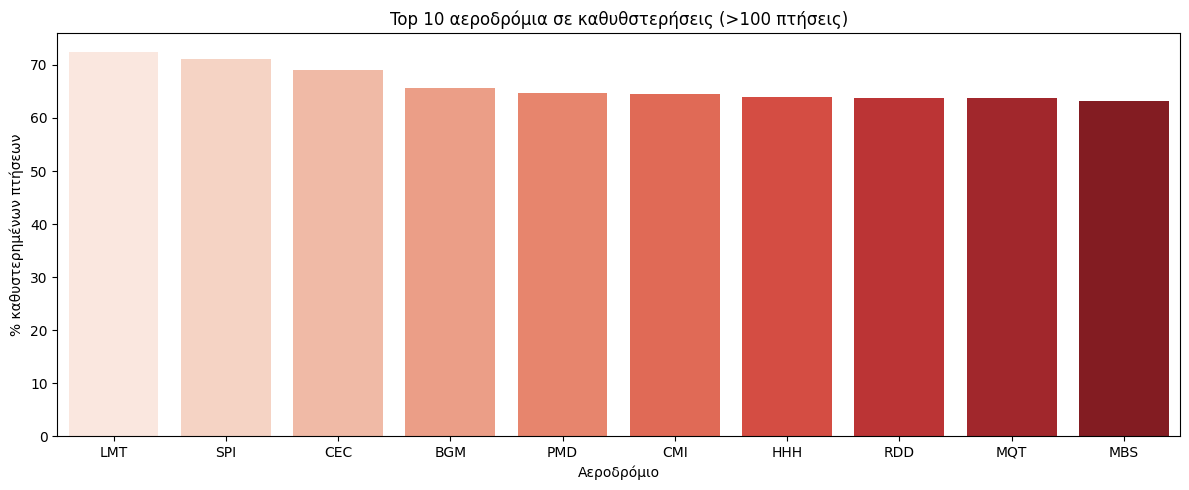

In [15]:
# Top 10 αεροδρόμια σε καθυστερήσεις
plt.figure(figsize=(12, 5))

# Φιλτράρισμα αεροδρομίων με > 100 πτήσεις
flight_counts = df.groupby("Origin")["DELAYED"].count()
valid_airports = flight_counts[flight_counts > 100].index

top_airports = df[df["Origin"].isin(valid_airports)].groupby("Origin")["DELAYED"].mean() * 100
top_airports = top_airports.sort_values(ascending=False).head(10)

sns.barplot(x=top_airports.index, y=top_airports.values, palette="Reds")
plt.title("Top 10 αεροδρόμια σε καθυθστερήσεις (>100 πτήσεις)")
plt.xlabel("Αεροδρόμιο")
plt.ylabel("% καθυστερημένων πτήσεων")
plt.tight_layout()
plt.show()

- Σημείωση: το φίλτρο των > 100 πτήσεων χρησιμοποιήθηκε για να μην ληφθούν υπόψη αεροδρόμια με πολύ λίγες πτήσεις που εμφάνιζαν καθυστερήσεις του 100%.
- Παρατηρήσεις: Όλα είναι μικρά περιφερειακά αεροδρόμια των ΗΠΑ, δεν εμφανίζεται κάποιο μεγάλο hub (π.χ. JFK). Η γεωγραφική διασπορά είναι μεγάλη, άρα δεν φταίει μια συγκεκριμένη περιοχή αλλά το μέγεθος και η εξάρτηση από λίγες πτήσεις. Η διαφορά μεταξύ του 1ου (~70%) και του 10ου (~60%), μας δείχνει πως η λίστα είναι αρκετά ομοιογενής.

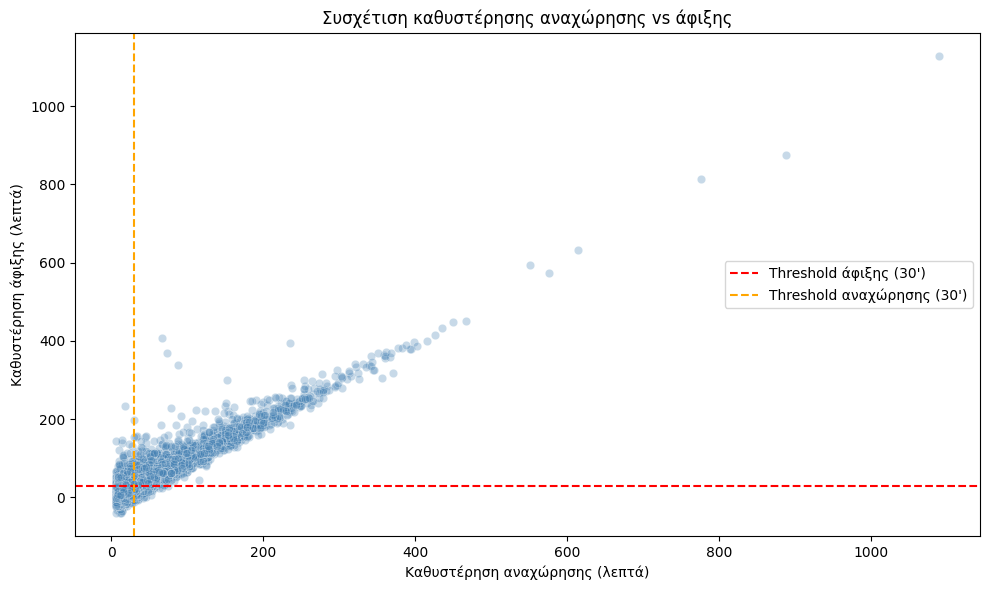

In [ ]:
# Scatter plot DepDelay vs ArrDelay
plt.figure(figsize=(10, 6))

df_sample = df.sample(10000, random_state=42)   #Δείγμα 10000 γραμμών για να μην είναι πολύ βαρύ

sns.scatterplot(x="DepDelay", y="ArrDelay", data=df_sample,
                alpha=0.3, color="steelblue")
plt.title("Συσχέτιση καθυστέρησης αναχώρησης vs άφιξης")
plt.xlabel("Καθυστέρηση αναχώρησης (λεπτά)")
plt.ylabel("Καθυστέρηση άφιξης (λεπτά)")
plt.axhline(y=30, color="red", linestyle="--", label="Threshold άφιξης (30')")
plt.axvline(x=30, color="orange", linestyle="--", label="Threshold αναχώρησης (30')")
plt.legend()
plt.tight_layout()
plt.show()

Τα σημεία ακολουθούν σαφώς μια γραμμική τάση κατά μήκος της διαγωνίου, επιβεβαιώνοντας οπτικά τη συσχέτιση 0.95 που είδαμε στο heatmap. Η καθυστέρηση αναχώρησης "μεταφράζεται" σχεδόν 1:1 σε καθυστέρηση άφιξης. Υπάρχουν εμφανή ακραία σημεία (>500' αναχώρηση ή >800' άφιξη) που αντιστοιχούν σε εξαιρετικές περιπτώσεις. 